# Huấn luyện Naive Bayes

**Naive Bayes** dựa trên xác suất (định lý Bayes), chạy rất nhanh.

> Nhớ chạy `02_tien_xu_ly/tien_xu_ly_data.ipynb` trước để có `features.csv`.

## Naive Bayes hoạt động thế nào? (công thức)

Dựa trên **định lý Bayes**, chọn bệnh có **xác suất hậu nghiệm** cao nhất:

$$P(\text{bệnh}\mid \text{triệu chứng}) \;\propto\; P(\text{bệnh})\;\prod_{j=1}^{135} P(\text{triệu chứng}_j\mid \text{bệnh})$$

Chữ **"Naive"** = giả định các triệu chứng **độc lập** với nhau khi đã biết bệnh → được phép **nhân** xác suất từng triệu chứng, nên rất nhanh.

Đặc trưng của ta là **số** (trọng số mức độ nặng) nên dùng **GaussianNB**: mỗi triệu chứng trong mỗi bệnh được mô hình hóa bằng phân phối chuẩn $N(\mu,\sigma^2)$

$$P(x_j\mid \text{bệnh})=\frac{1}{\sqrt{2\pi\sigma^2}}\;\exp\!\left(-\frac{(x_j-\mu)^2}{2\sigma^2}\right)$$

**Tham số chính – `var_smoothing`:** cộng một lượng nhỏ vào $\sigma^2$ để tránh chia cho 0 khi một triệu chứng gần như không đổi → giúp ổn định số học.

> Naive Bayes **huấn luyện cực nhanh** và xuất ra **xác suất từng bệnh** — rất hợp để gợi ý "danh sách bệnh khả dĩ" cho chatbot.

## Bước 1. Đọc dữ liệu đã tiền xử lý

In [1]:
from sklearn.naive_bayes import GaussianNB
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu đã tiền xử lý (chạy notebook tien_xu_ly_data.ipynb trước)
data = pd.read_csv("../01_data/processed/features.csv")

X = data.drop(columns=["Benh"])     # các cột triệu chứng
y = data["Benh"]                    # nhãn bệnh (dạng chữ)

le = LabelEncoder()
y_num = le.fit_transform(y)         # đổi nhãn chữ -> số

X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, test_size=0.2, random_state=42, stratify=y_num)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Số bệnh:", len(le.classes_))


Train: (4000, 135) | Test: (1000, 135) | Số bệnh: 400


## Bước 2. Huấn luyện và đánh giá

In [2]:
from sklearn.metrics import accuracy_score

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Độ chính xác trên tập test:", round(accuracy_score(y_test, y_pred), 3))


Độ chính xác trên tập test: 0.316


## Bước 3. Đường cong học tập theo tham số

Thử nhiều giá trị của **`var_smoothing`** để xem mô hình tốt nhất ở đâu.
- Đường **Train** cao mà **Kiểm tra (CV)** thấp ⇒ **quá khớp** (overfitting).
- Cả hai cùng thấp ⇒ **chưa khớp** (underfitting).


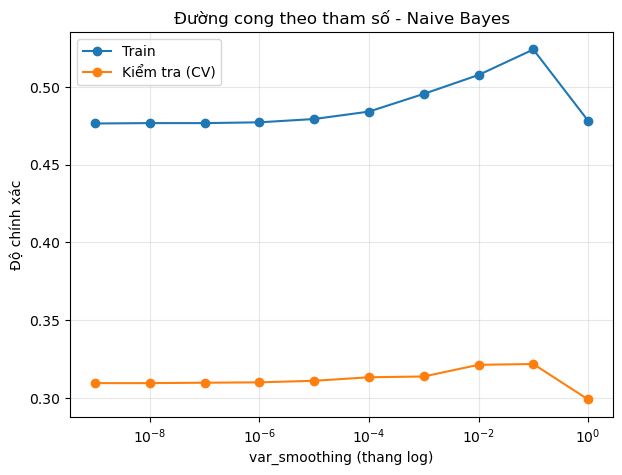

Giá trị var_smoothing tốt nhất: 0.1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

gia_tri = list(np.logspace(-9, 0, 10))
train_sc, val_sc = validation_curve(
    GaussianNB(), X_train, y_train,
    param_name="var_smoothing", param_range=gia_tri,
    cv=3, scoring="accuracy")

plt.figure(figsize=(7,5))
plt.plot(gia_tri, train_sc.mean(axis=1), "o-", label="Train")
plt.plot(gia_tri, val_sc.mean(axis=1), "o-", label="Kiểm tra (CV)")
plt.xscale("log")
plt.xlabel("var_smoothing (thang log)"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo tham số - Naive Bayes")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

tot_nhat = gia_tri[int(np.argmax(val_sc.mean(axis=1)))]
print("Giá trị var_smoothing tốt nhất:", tot_nhat)


## Bước 4. Đường cong học tập theo số lượng mẫu

Xem mô hình có học tốt hơn khi có **nhiều dữ liệu** hơn không.

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


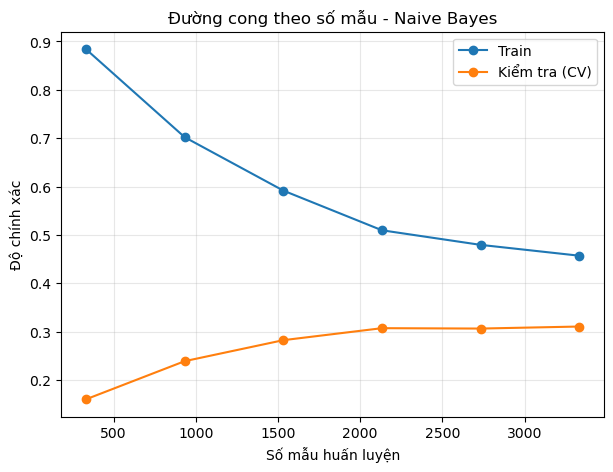

In [5]:
from sklearn.model_selection import learning_curve

sizes, train_sc2, val_sc2 = learning_curve(
    model, X, y_num, cv=3, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6))

plt.figure(figsize=(7,5))
plt.plot(sizes, train_sc2.mean(axis=1), "o-", label="Train")
plt.plot(sizes, val_sc2.mean(axis=1), "o-", label="Kiểm tra (CV)")
plt.xlabel("Số mẫu huấn luyện"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo số mẫu - Naive Bayes")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


## Bước 5. Lưu mô hình

In [6]:
import pickle
with open("naive_bayes_model.pkl", "wb") as f:
    pickle.dump({"model": model, "label_encoder": le}, f)
print("Đã lưu naive_bayes_model.pkl")


Đã lưu naive_bayes_model.pkl
